# 🎭 Análisis Avanzado de Landmarks Faciales con MediaPipe

**Materiales desarrollados por Matías Barreto, 2026**  
**Tecnicatura Superior en Ciencias de Datos e IA, IFTS24**  
* **Nomenclatura Oficial:** Procesamiento Digital de Imágenes  
* **Nombre de Trabajo:** Laboratorio de Tecnologías de la Imagen Digital  

---

## Objetivo

En este notebook continuamos desde la detección básica de los **478 puntos clave** del rostro y agregamos cuatro capacidades nuevas:

1. **Visualización selectiva**: dibujar solo los landmarks de los ojos.
2. **Colores por región**: asignar un color diferente a cada zona del rostro.
3. **Landmarks numerados**: mostrar el índice de cada punto sobre la imagen.
4. **Medición de distancias**: calcular el ancho de la boca y otras métricas en píxeles.
5. **Malla facial**: conectar landmarks con líneas para construir una red geométrica.
6. **Detección de expresiones**: identificar si la boca está abierta o cerrada usando un ratio.

## Al terminar este material vamos a poder:

1. Seleccionar subconjuntos de landmarks por su índice numérico.
2. Colorear regiones del rostro de forma independiente.
3. Superponer texto sobre la imagen con `cv2.putText()`.
4. Calcular distancias euclidianas entre puntos normalizados.
5. Dibujar líneas de conexión con `cv2.line()` para formar una malla.
6. Tomar decisiones automáticas basadas en umbrales geométricos.

## Microglosario

Términos nuevos que vamos a usar en este notebook.

| Término | Definición | Analogía |
|---|---|---|
| **Distancia euclidiana** | Longitud del segmento recto entre dos puntos, calculada con el Teorema de Pitágoras: √((x₂−x₁)² + (y₂−y₁)²) | Como medir con una regla la distancia más corta entre dos pines en un mapa |
| **Ratio** | Cociente entre dos medidas del mismo tipo; no tiene unidades | Como comparar el ancho de una puerta con su alto: si el ratio es 0.5, es el doble de alta que ancha |
| **Umbral (threshold)** | Valor límite que separa dos estados: si el valor supera el umbral, cambia la decisión | Como el termostato de un calefactor: por encima de 20 °C se apaga, por debajo se enciende |
| **Malla (mesh)** | Red de segmentos que conectan puntos para formar la superficie geométrica de un objeto | Como la malla metálica de un arco de fútbol: los vértices son los landmarks, los alambres son las conexiones |
| **Región facial** | Subconjunto de landmarks que pertenecen a una misma zona anatómica (ojos, nariz, labios…) | Como los barrios de una ciudad: comparten frontera pero tienen identidad propia |
| **`cv2.putText()`** | Función de OpenCV que escribe texto sobre una imagen en una posición, fuente y color dados | Como usar un rotulador sobre una fotocopia: el original queda intacto si trabajamos sobre una copia |
| **`cv2.line()`** | Función de OpenCV que dibuja un segmento entre dos puntos sobre una imagen | Como trazar una línea con regla entre dos pines en un mapa |

---

## 1. Instalación de Bibliotecas

Instalamos las mismas dependencias que en el notebook anterior. Si ya las tenés instaladas, la celda se ejecuta rápidamente sin volver a descargar.

---

In [1]:
# Instala las dependencias del notebook en el kernel activo.
# mediapipe 0.10.13+ (Tasks API) para Python 3.12; opencv-python-headless evita conflictos con Qt.
%pip install mediapipe opencv-python-headless numpy matplotlib --quiet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Importación de Bibliotecas

Importamos exactamente las mismas bibliotecas que usamos en el notebook base. La verificación de versiones al final nos confirma que el entorno está listo.

---

In [2]:
# =============================================================================
# Importaciones y verificación de versiones del entorno.
# =============================================================================

import math
import os
import urllib.request

import cv2
import mediapipe as mp
import numpy as np
import matplotlib.pyplot as plt

from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision

print('✓ Entorno listo.')
print(f'  mediapipe  {mp.__version__}')
print(f'  opencv     {cv2.__version__}')
print(f'  numpy      {np.__version__}')
print('✓ Bibliotecas cargadas correctamente.')

✓ Entorno listo.
  mediapipe  0.10.35
  opencv     4.13.0
  numpy      2.4.6
✓ Bibliotecas cargadas correctamente.


## 3. Carga de Imagen

### ¿Qué imagen vamos a usar?

Podemos usar cualquier foto con uno o dos rostros visibles. Para cambiar la imagen, basta con editar `ruta_imagen` con el nombre del archivo (que debe estar en la misma carpeta que este notebook).

### Recordatorio: BGR vs RGB

- **OpenCV** carga imágenes en **BGR** (Azul-Verde-Rojo).
- **MediaPipe** espera **RGB** (Rojo-Verde-Azul).
- **Matplotlib** también muestra en **RGB**.

Por eso trabajamos con dos versiones de la imagen:
- `imagen` → BGR, para operaciones de dibujo con OpenCV.
- `imagen_rgb` → RGB, para enviar a MediaPipe y mostrar con Matplotlib.

---

In [3]:
# =============================================================================
# Carga la imagen desde disco y la prepara para MediaPipe.
# Cambiar ruta_imagen para usar una foto propia.
# =============================================================================

ruta_imagen = 'xavi_y_yo.jpg'

imagen = cv2.imread(ruta_imagen)

if imagen is None:
    print(f'✗ No se pudo cargar "{ruta_imagen}".')
    print('  Verificá que el archivo esté en la misma carpeta que este notebook.')
else:
    alto, ancho = imagen.shape[:2]
    imagen_rgb = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)

    print('✓ Imagen cargada.')
    print(f'  Dimensiones: {ancho} × {alto} px')
    print('✓ Conversión BGR → RGB completada.')

✓ Imagen cargada.
  Dimensiones: 2320 × 1740 px
✓ Conversión BGR → RGB completada.


## 4. Configuración del Detector y Detección

### ¿Qué hace esta celda?

1. Descarga el modelo `face_landmarker.task` si no existe en disco.
2. Configura el `FaceLandmarker` con la Tasks API de MediaPipe.
3. Ejecuta la detección y guarda los resultados en `resultados`.

Los resultados se reutilizan en **todas** las celdas siguientes: no es necesario volver a ejecutar la detección para cada visualización.

### Parámetros importantes

| Parámetro | Valor | Significado |
|---|---|---|
| `num_faces` | `2` | Busca hasta 2 rostros en la imagen |
| `min_face_detection_confidence` | `0.5` | Acepta detecciones con al menos 50 % de confianza |

---

In [4]:
# =============================================================================
# Descarga el modelo, inicializa el detector y ejecuta la detección.
# Los resultados quedan en la variable global `resultados` para uso posterior.
# =============================================================================

modelo_path = 'face_landmarker.task'

if not os.path.exists(modelo_path):
    print('Descargando modelo (~5 MB)...')
    urllib.request.urlretrieve(
        'https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task',
        modelo_path
    )
    print('✓ Modelo descargado.')
else:
    print(f'✓ Modelo disponible: {modelo_path}')

base_options = mp_python.BaseOptions(model_asset_path=modelo_path)
opciones = mp_vision.FaceLandmarkerOptions(
    base_options=base_options,
    num_faces=2,
    min_face_detection_confidence=0.5
)
detector_facial = mp_vision.FaceLandmarker.create_from_options(opciones)

imagen_mp = mp.Image(image_format=mp.ImageFormat.SRGB, data=imagen_rgb)
resultados = detector_facial.detect(imagen_mp)
detector_facial.close()

n_rostros = len(resultados.face_landmarks) if resultados.face_landmarks else 0
print(f'\n✓ Detección completada: {n_rostros} rostro(s) encontrado(s).')
if n_rostros > 0:
    print(f'  Landmarks por rostro: {len(resultados.face_landmarks[0])}')

✓ Modelo disponible: face_landmarker.task

✓ Detección completada: 2 rostro(s) encontrado(s).
  Landmarks por rostro: 478


---

## PARTE 1 — Visualización Avanzada de Landmarks

En esta parte resolvemos las tres consignas de visualización:

| Consigna | Tarea |
|---|---|
| **1** | Dibujar **solo** los landmarks de los ojos (índices 33, 133, 362, 263) |
| **2** | Usar **colores diferentes** para cada región del rostro |
| **3** | Mostrar el **número de índice** de cada landmark sobre la imagen |

---

### Consigna 1: Solo los landmarks de los ojos

#### ¿Qué puntos son el 33, 133, 362 y 263?

En el modelo FaceMesh de MediaPipe, cuatro índices específicos marcan las **esquinas de los ojos**:

| Índice | Ubicación |
|---|---|
| **33** | Esquina exterior del ojo derecho *(perspectiva de la cámara)* |
| **133** | Esquina interior del ojo derecho *(perspectiva de la cámara)* |
| **362** | Esquina interior del ojo izquierdo *(perspectiva de la cámara)* |
| **263** | Esquina exterior del ojo izquierdo *(perspectiva de la cámara)* |

#### ¿Cómo seleccionamos solo esos puntos?

En el notebook base dibujamos todos los landmarks con un bucle sobre los 478 índices. Acá usamos una **lista de índices elegidos** y solo dibujamos los puntos que están en esa lista:

```python
LANDMARKS_OJOS = [33, 133, 362, 263]

for idx in LANDMARKS_OJOS:
    punto = cara[idx]       # Accedemos al landmark por su índice
    x = int(punto.x * ancho)
    y = int(punto.y * alto)
    cv2.circle(imagen_ojos, (x, y), radio, color, -1)
```

---

✓ 4 landmarks de ojos por rostro.
  Índices: [33, 133, 362, 263]


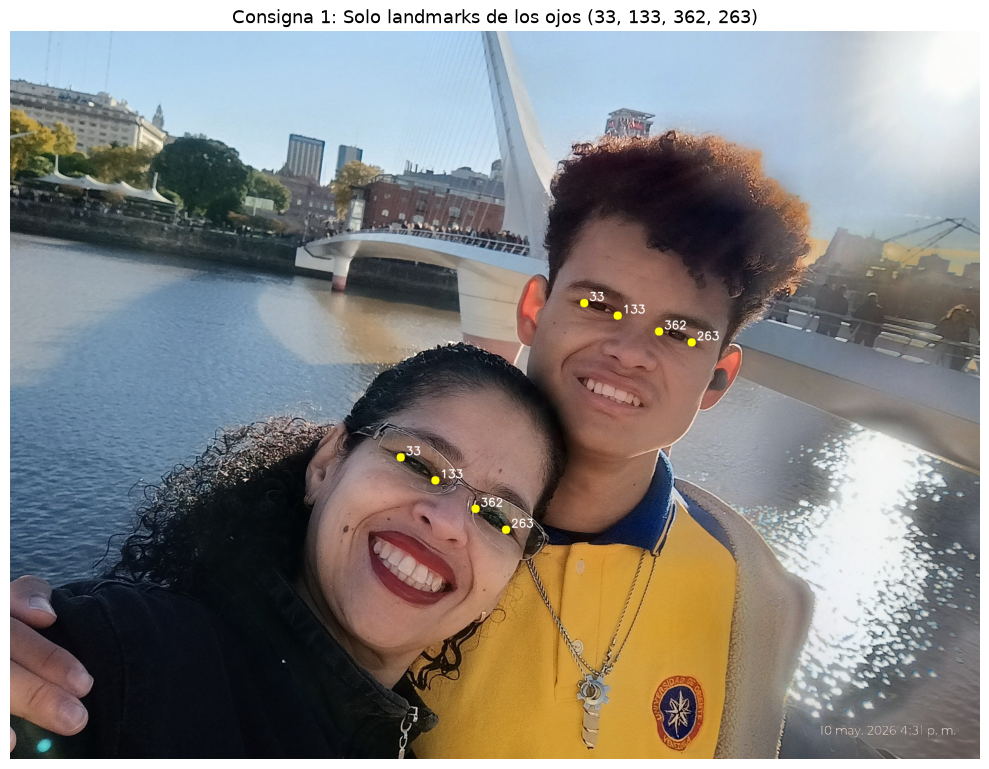

In [5]:
# =============================================================================
# Consigna 1: Dibujar únicamente los 4 landmarks de las esquinas de los ojos.
# Se accede a cada landmark por su índice numérico dentro de la lista de 478.
# =============================================================================

# Los 4 índices que marcan las esquinas internas y externas de ambos ojos.
# La perspectiva es desde la cámara, no desde el sujeto.
LANDMARKS_OJOS = [33, 133, 362, 263]

# Trabajamos sobre una copia en BGR para no modificar la imagen original.
imagen_ojos = imagen.copy()

if resultados.face_landmarks:
    for i, cara in enumerate(resultados.face_landmarks):
        for idx in LANDMARKS_OJOS:
            punto = cara[idx]
            # Convertir coordenadas normalizadas (0.0–1.0) a píxeles.
            x = int(punto.x * ancho)
            y = int(punto.y * alto)

            # Círculo amarillo (BGR: 0, 255, 255) radio=10, relleno (-1).
            cv2.circle(imagen_ojos, (x, y), 10, (0, 255, 255), -1)

            # Etiqueta con el índice del landmark al costado del punto.
            cv2.putText(
                imagen_ojos,
                str(idx),
                (x + 12, y - 6),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.9,
                (255, 255, 255),
                2
            )

    print(f'✓ {len(LANDMARKS_OJOS)} landmarks de ojos por rostro.')
    print(f'  Índices: {LANDMARKS_OJOS}')
else:
    print('✗ No se detectaron rostros.')

# Matplotlib espera RGB; convertimos antes de mostrar.
plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(imagen_ojos, cv2.COLOR_BGR2RGB))
plt.title('Consigna 1: Solo landmarks de los ojos (33, 133, 362, 263)', fontsize=13)
plt.axis('off')
plt.tight_layout()
plt.show()

### Consigna 2: Diferentes colores para diferentes partes del rostro

#### ¿Cómo saber qué índice pertenece a qué región?

La documentación de MediaPipe publica la lista completa de 478 landmarks con su región anatómica. Para este ejercicio usamos los grupos más importantes:

| Región | Color (BGR) | Color visual |
|---|---|---|
| Ojo derecho *(cámara)* | `(0, 255, 255)` | Amarillo |
| Ojo izquierdo *(cámara)* | `(255, 255, 0)` | Cyan |
| Labios | `(0, 0, 255)` | Rojo |
| Nariz | `(0, 165, 255)` | Naranja |
| Cejas | `(0, 255, 0)` | Verde |
| Contorno facial | `(255, 0, 255)` | Magenta |
| Resto (sin clasificar) | `(128, 128, 128)` | Gris |

#### Estrategia de implementación

Construimos un **diccionario de regiones**, donde cada entrada contiene el conjunto de índices y el color asignado. Antes de iterar sobre los 478 landmarks, generamos un **mapa índice → color** para que la búsqueda del color de cada punto sea O(1).

**Analogía**: Es como tener un plano de la ciudad donde cada barrio tiene su color. Antes de pintar, hacemos una tabla que dice "si estás en el barrio X, usá el color Y".

---

✓ Landmarks dibujados con colores por región.
  Ojo derecho (cámara): 16 puntos
  Ojo izquierdo (cámara): 16 puntos
  Labios: 40 puntos
  Nariz: 21 puntos
  Cejas: 20 puntos
  Contorno facial: 36 puntos
  Sin clasificar: 329 puntos (gris)


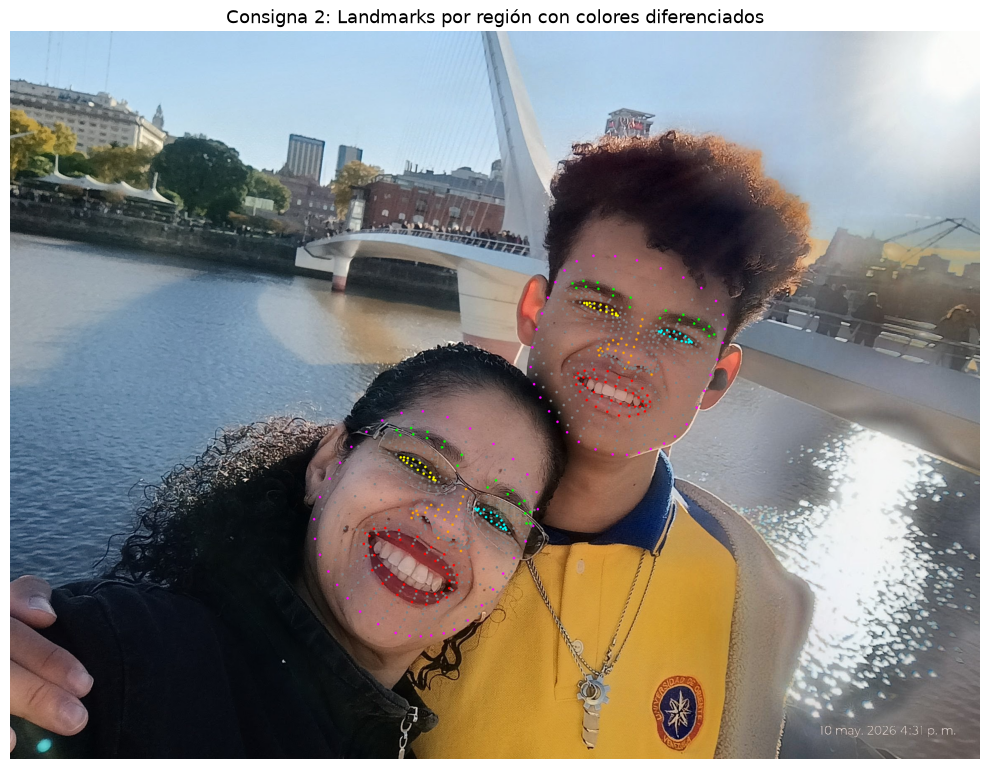

In [6]:
# =============================================================================
# Consigna 2: Colorear cada landmark según la región anatómica a la que pertenece.
# Los índices de cada región se obtienen del modelo FaceMesh de 478 puntos.
# =============================================================================

# Definición de regiones: cada una tiene un conjunto de índices y un color BGR.
REGIONES = {
    'ojo_derecho': {
        'indices': {33, 7, 163, 144, 145, 153, 154, 155, 133, 173, 157, 158, 159, 160, 161, 246},
        'color': (0, 255, 255),    # Amarillo BGR
        'nombre': 'Ojo derecho (cámara)'
    },
    'ojo_izquierdo': {
        'indices': {362, 382, 381, 380, 374, 373, 390, 249, 263, 466, 388, 387, 386, 385, 384, 398},
        'color': (255, 255, 0),    # Cyan BGR
        'nombre': 'Ojo izquierdo (cámara)'
    },
    'labios': {
        'indices': {
            61, 185, 40, 39, 37, 0, 267, 269, 270, 409, 291, 375, 321, 405, 314,
            17, 84, 181, 91, 146, 78, 191, 80, 81, 82, 13, 312, 311, 310, 415,
            308, 324, 318, 402, 317, 14, 87, 178, 88, 95
        },
        'color': (0, 0, 255),      # Rojo BGR
        'nombre': 'Labios'
    },
    'nariz': {
        'indices': {1, 2, 4, 5, 6, 45, 48, 51, 64, 98, 115, 131, 134, 168, 195, 197, 198, 219, 220, 236, 327},
        'color': (0, 165, 255),    # Naranja BGR
        'nombre': 'Nariz'
    },
    'cejas': {
        'indices': {46, 52, 53, 55, 63, 65, 66, 70, 105, 107, 276, 282, 283, 285, 293, 295, 296, 300, 334, 336},
        'color': (0, 255, 0),      # Verde BGR
        'nombre': 'Cejas'
    },
    'contorno': {
        'indices': {
            10, 21, 54, 58, 67, 93, 103, 109, 127, 132, 136, 148, 149, 150, 152,
            162, 172, 176, 234, 251, 284, 288, 297, 323, 332, 338, 356, 361, 365,
            377, 378, 379, 389, 397, 400, 454
        },
        'color': (255, 0, 255),    # Magenta BGR
        'nombre': 'Contorno facial'
    },
}

COLOR_DEFECTO = (128, 128, 128)  # Gris para landmarks sin clasificar.

# Construir mapa índice → color para búsqueda O(1) al iterar los 478 puntos.
mapa_colores = {}
for region in REGIONES.values():
    for idx in region['indices']:
        mapa_colores[idx] = region['color']

imagen_colores = imagen.copy()

if resultados.face_landmarks:
    for cara in resultados.face_landmarks:
        for idx, punto in enumerate(cara):
            x = int(punto.x * ancho)
            y = int(punto.y * alto)
            color = mapa_colores.get(idx, COLOR_DEFECTO)
            cv2.circle(imagen_colores, (x, y), 3, color, -1)

    print('✓ Landmarks dibujados con colores por región.')
    for datos in REGIONES.values():
        print(f'  {datos["nombre"]}: {len(datos["indices"])} puntos')
    clasificados = sum(len(d['indices']) for d in REGIONES.values())
    print(f'  Sin clasificar: {478 - clasificados} puntos (gris)')
else:
    print('✗ No se detectaron rostros.')

plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(imagen_colores, cv2.COLOR_BGR2RGB))
plt.title('Consigna 2: Landmarks por región con colores diferenciados', fontsize=13)
plt.axis('off')
plt.tight_layout()
plt.show()

### Consigna 3: Número de índice sobre cada landmark

#### La función `cv2.putText()`

Para escribir texto sobre una imagen usamos:

```python
cv2.putText(
    imagen,              # Imagen sobre la que dibujar (se modifica en el lugar).
    'texto',             # Texto a escribir.
    (x, y),             # Coordenadas de la esquina inferior izquierda del texto.
    cv2.FONT_HERSHEY_SIMPLEX,   # Tipografía.
    escala_fuente,       # Tamaño relativo de la fuente (0.3 = muy pequeño).
    (B, G, R),           # Color del texto en formato BGR.
    grosor               # Grosor del trazo en píxeles.
)
```

#### ¿Por qué la fuente es tan pequeña?

Con 478 números distribuidos en el rostro, usar una fuente grande haría que los textos se superpongan y resulten ilegibles. Con `escala_fuente=0.25` y una imagen grande (2000+ px), cada número ocupa aproximadamente 15×10 píxeles, suficiente para leerlos con zoom.

**Consejo**: Si la imagen es pequeña (menos de 800 px de ancho), aumentá la escala a `0.4` o `0.5` y dibujá menos landmarks para que los números sean legibles.

---

✓ 478 landmarks numerados.
  Nota: usá zoom en la imagen para leer los números individuales.


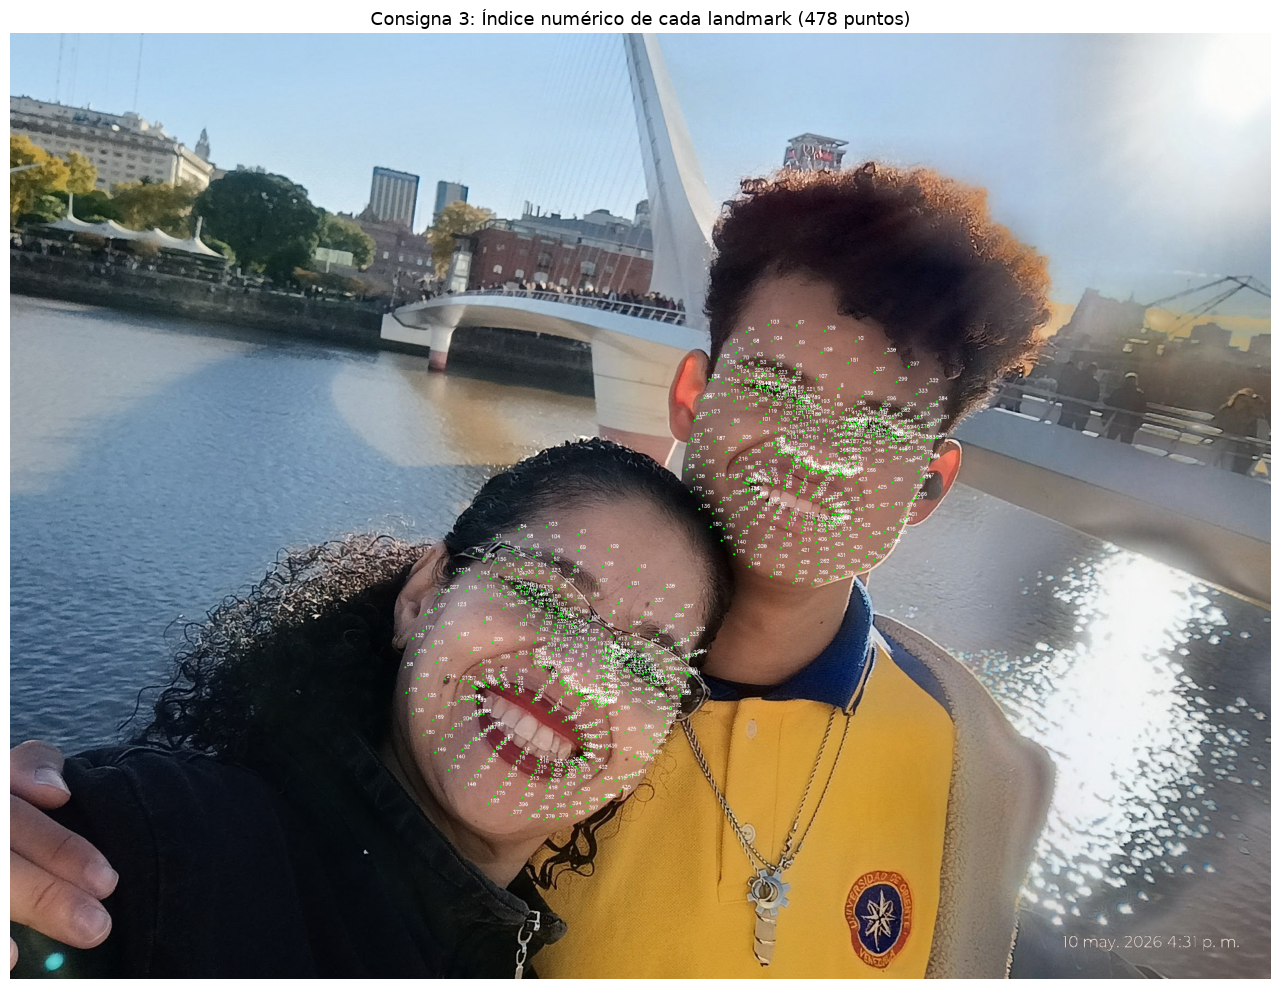

In [7]:
# =============================================================================
# Consigna 3: Mostrar el número de índice de cada uno de los 478 landmarks.
# Se usa fuente pequeña para que los 478 números entren sin sobreponerse.
# =============================================================================

imagen_numerada = imagen.copy()

if resultados.face_landmarks:
    for cara in resultados.face_landmarks:
        for idx, punto in enumerate(cara):
            x = int(punto.x * ancho)
            y = int(punto.y * alto)

            # Punto pequeño como referencia visual del landmark.
            cv2.circle(imagen_numerada, (x, y), 2, (0, 255, 0), -1)

            # Número del landmark: fuente pequeña para no saturar la imagen.
            cv2.putText(
                imagen_numerada,
                str(idx),
                (x + 3, y - 3),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.28,             # Escala pequeña: ajustar a 0.4 si la imagen es chica.
                (255, 255, 255),  # Texto blanco para contraste sobre cualquier fondo.
                1
            )

    total_pts = len(resultados.face_landmarks[0])
    print(f'✓ {total_pts} landmarks numerados.')
    print('  Nota: usá zoom en la imagen para leer los números individuales.')
else:
    print('✗ No se detectaron rostros.')

# Figura más grande para que los números sean legibles al hacer zoom.
plt.figure(figsize=(14, 10))
plt.imshow(cv2.cvtColor(imagen_numerada, cv2.COLOR_BGR2RGB))
plt.title('Consigna 3: Índice numérico de cada landmark (478 puntos)', fontsize=13)
plt.axis('off')
plt.tight_layout()
plt.show()

---

## PARTE 2 — Medición de Distancias entre Landmarks

### ¿Por qué medir distancias?

Las distancias entre landmarks son la base de muchas aplicaciones:

- **Filtros de realidad aumentada**: para escalar correctamente una corona o una máscara.
- **Diagnóstico médico**: para medir asimetrías faciales.
- **Detección de emociones**: el ancho de la sonrisa o la apertura de la boca.

### Fórmula: Distancia euclidiana

Dados dos puntos P₁ = (x₁, y₁) y P₂ = (x₂, y₂), la distancia es:

```
d = √((x₂ − x₁)² + (y₂ − y₁)²)
```

En Python: `math.sqrt((x2 - x1)**2 + (y2 - y1)**2)`

### Landmarks que vamos a usar

| Medición | Landmark inicio | Landmark fin |
|---|---|---|
| Ancho de la boca | 61 (comisura izquierda en imagen) | 291 (comisura derecha en imagen) |
| Apertura de la boca | 13 (labio superior interno) | 14 (labio inferior interno) |
| Distancia interior ojos | 133 (canto interior ojo derecho) | 362 (canto interior ojo izquierdo) |
| Distancia exterior ojos | 33 (canto exterior ojo derecho) | 263 (canto exterior ojo izquierdo) |

---

MEDICIONES POR ROSTRO (en píxeles)

  Rostro 1:
    Ancho boca                   193.6 px
    Apertura boca                 35.6 px
    Distancia int. ojos          105.4 px
    Distancia ext. ojos          273.4 px

  Rostro 2:
    Ancho boca                   249.8 px
    Apertura boca                 88.7 px
    Distancia int. ojos          118.0 px
    Distancia ext. ojos          305.7 px

✓ Líneas de medición dibujadas.


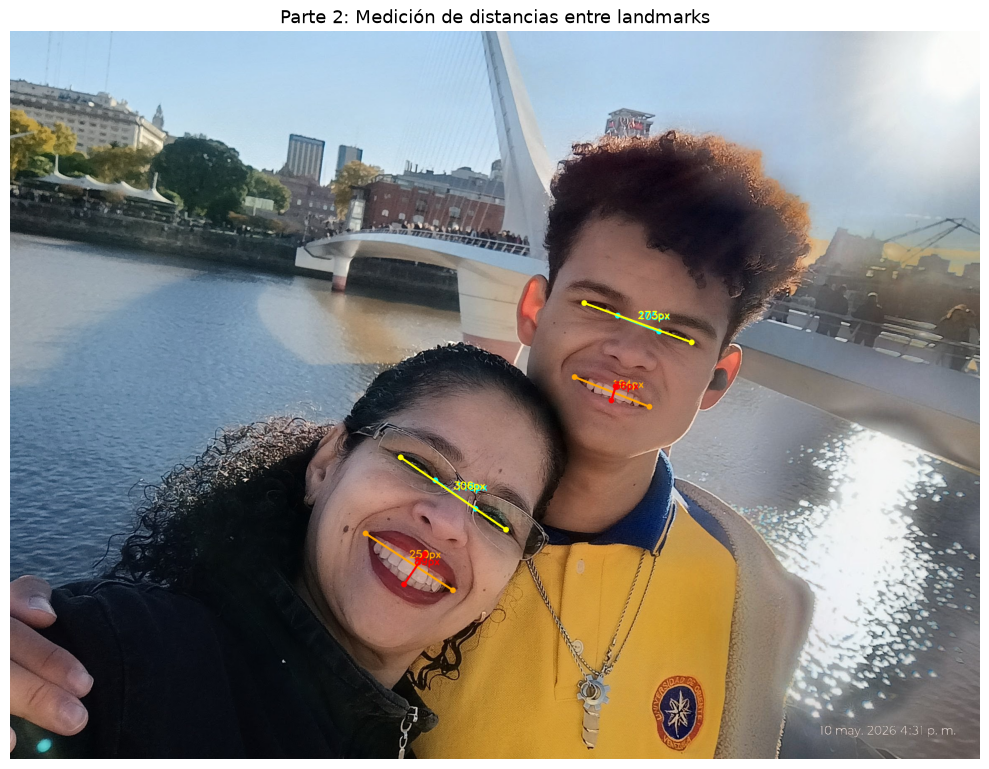

In [8]:
# =============================================================================
# Parte 2: Medir distancias entre landmarks y dibujar las líneas de medición.
# La función dist_px centraliza el cálculo para evitar repetición.
# =============================================================================

def dist_px(lm1, lm2, img_ancho, img_alto):
    """Distancia euclidiana en píxeles entre dos NormalizedLandmarks."""
    x1, y1 = lm1.x * img_ancho, lm1.y * img_alto
    x2, y2 = lm2.x * img_ancho, lm2.y * img_alto
    return math.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2)

def coords_px(lm, img_ancho, img_alto):
    """Convierte un NormalizedLandmark a tupla de píxeles (x, y)."""
    return (int(lm.x * img_ancho), int(lm.y * img_alto))


# Pares de landmarks para cada medición: (índice_A, índice_B, nombre, color_BGR)
MEDICIONES = [
    (61,  291, 'Ancho boca',           (0, 165, 255)),  # Naranja
    (13,  14,  'Apertura boca',         (0, 0,   255)),  # Rojo
    (133, 362, 'Distancia int. ojos',   (255, 255, 0)),  # Cyan
    (33,  263, 'Distancia ext. ojos',   (0, 255, 255)),  # Amarillo
]

imagen_distancias = imagen.copy()

print('=' * 52)
print('MEDICIONES POR ROSTRO (en píxeles)')
print('=' * 52)

if resultados.face_landmarks:
    for i, cara in enumerate(resultados.face_landmarks):
        print(f'\n  Rostro {i + 1}:')

        for idx_a, idx_b, nombre, color in MEDICIONES:
            p1 = coords_px(cara[idx_a], ancho, alto)
            p2 = coords_px(cara[idx_b], ancho, alto)
            distancia = dist_px(cara[idx_a], cara[idx_b], ancho, alto)

            # Dibujar la línea de medición sobre la imagen.
            cv2.line(imagen_distancias, p1, p2, color, 3)

            # Marcar los extremos con círculos.
            cv2.circle(imagen_distancias, p1, 7, color, -1)
            cv2.circle(imagen_distancias, p2, 7, color, -1)

            # Escribir la distancia en el punto medio del segmento.
            mid_x = (p1[0] + p2[0]) // 2
            mid_y = (p1[1] + p2[1]) // 2 - 10
            cv2.putText(
                imagen_distancias,
                f'{distancia:.0f}px',
                (mid_x, mid_y),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.8, color, 2
            )

            print(f'    {nombre:<26} {distancia:>7.1f} px')

    print()
    print('✓ Líneas de medición dibujadas.')
else:
    print('✗ No se detectaron rostros.')

plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(imagen_distancias, cv2.COLOR_BGR2RGB))
plt.title('Parte 2: Medición de distancias entre landmarks', fontsize=13)
plt.axis('off')
plt.tight_layout()
plt.show()

---

## PARTE 3 — Malla Facial: Conectar Landmarks con Líneas

### ¿Qué es una malla?

Una **malla** (del inglés *mesh*) es un conjunto de segmentos que conectan puntos para describir la superficie de un objeto en 3D (o su proyección en 2D). En visión artificial se usa para:

- Representar la geometría del rostro de forma compacta.
- Interpolar la deformación entre landmarks al aplicar filtros.
- Visualizar la estructura subyacente de la detección.

### ¿Cómo definimos las conexiones?

Cada conexión es un **par de índices** (A, B) que indica que debemos trazar un segmento entre el landmark A y el landmark B. En la librería oficial de MediaPipe estas conexiones se publican como constantes (`FACEMESH_CONTOURS`, `FACEMESH_TESSELATION`, etc.). En este notebook las definimos **manualmente** por región para entender mejor qué conecta qué.

**Colores de las conexiones:**

| Región | Color |
|---|---|
| Contorno facial | Magenta |
| Ojos | Amarillo |
| Labios | Rojo |
| Nariz | Naranja |
| Cejas | Verde |

---

✓ Malla dibujada: 139 conexiones en 5 regiones.
  contorno    : 36 segmentos
  ojos        : 32 segmentos
  labios      : 40 segmentos
  nariz       : 13 segmentos
  cejas       : 18 segmentos


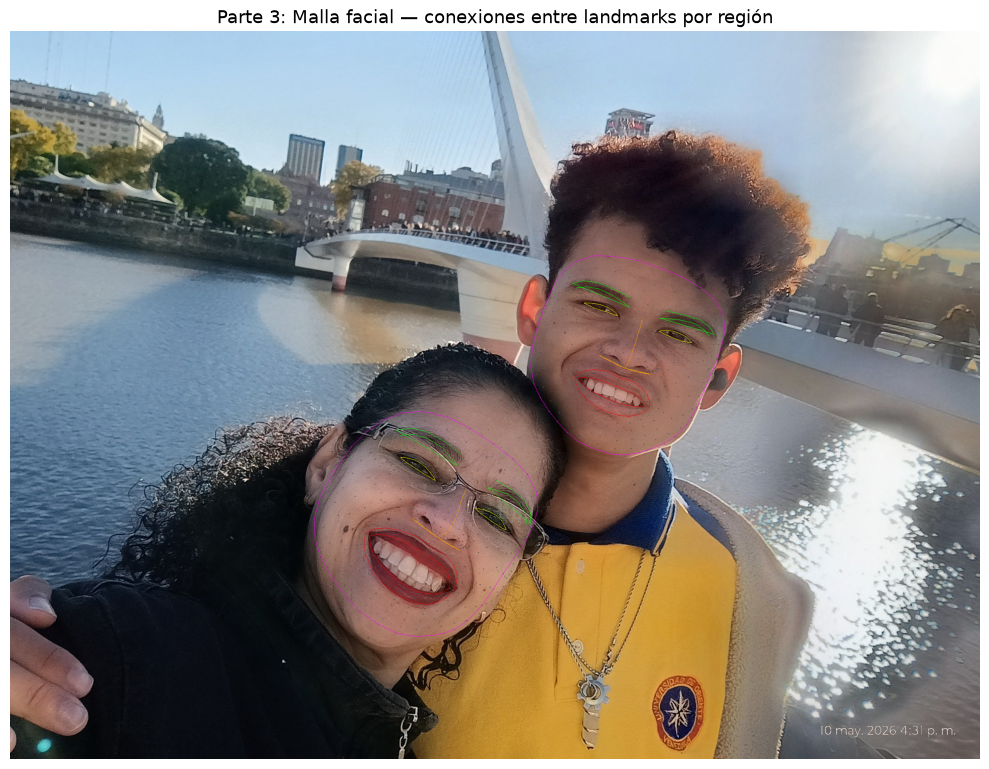

In [9]:
# =============================================================================
# Parte 3: Dibujar una malla facial conectando landmarks clave con líneas.
# Las conexiones están organizadas por región para asignar colores distintos.
# =============================================================================

CONEXIONES_MALLA = {
    'contorno': {
        'color': (255, 0, 255),   # Magenta BGR
        'pares': [
            (10, 338), (338, 297), (297, 332), (332, 284), (284, 251), (251, 389),
            (389, 356), (356, 454), (454, 323), (323, 361), (361, 288), (288, 397),
            (397, 365), (365, 379), (379, 378), (378, 400), (400, 377), (377, 152),
            (152, 148), (148, 176), (176, 149), (149, 150), (150, 136), (136, 172),
            (172, 58), (58, 132), (132, 93), (93, 234), (234, 127), (127, 162),
            (162, 21), (21, 54), (54, 103), (103, 67), (67, 109), (109, 10),
        ]
    },
    'ojos': {
        'color': (0, 255, 255),   # Amarillo BGR
        'pares': [
            # Ojo derecho (perspectiva cámara)
            (33, 7), (7, 163), (163, 144), (144, 145), (145, 153),
            (153, 154), (154, 155), (155, 133), (133, 173), (173, 157),
            (157, 158), (158, 159), (159, 160), (160, 161), (161, 246), (246, 33),
            # Ojo izquierdo (perspectiva cámara)
            (362, 382), (382, 381), (381, 380), (380, 374), (374, 373),
            (373, 390), (390, 249), (249, 263), (263, 466), (466, 388),
            (388, 387), (387, 386), (386, 385), (385, 384), (384, 398), (398, 362),
        ]
    },
    'labios': {
        'color': (0, 0, 255),     # Rojo BGR
        'pares': [
            # Contorno externo de la boca
            (61, 185), (185, 40), (40, 39), (39, 37), (37, 0), (0, 267),
            (267, 269), (269, 270), (270, 409), (409, 291), (291, 375),
            (375, 321), (321, 405), (405, 314), (314, 17), (17, 84),
            (84, 181), (181, 91), (91, 146), (146, 61),
            # Contorno interno de la boca
            (78, 191), (191, 80), (80, 81), (81, 82), (82, 13), (13, 312),
            (312, 311), (311, 310), (310, 415), (415, 308), (308, 324),
            (324, 318), (318, 402), (402, 317), (317, 14), (14, 87),
            (87, 178), (178, 88), (88, 95), (95, 78),
        ]
    },
    'nariz': {
        'color': (0, 165, 255),   # Naranja BGR
        'pares': [
            (168, 6), (6, 197), (197, 195), (195, 5), (5, 4), (4, 1),
            (1, 2), (2, 98), (98, 97), (97, 2), (2, 326), (326, 327), (327, 2),
        ]
    },
    'cejas': {
        'color': (0, 255, 0),     # Verde BGR
        'pares': [
            # Ceja derecha (perspectiva cámara)
            (46, 53), (53, 52), (52, 65), (65, 55), (55, 70),
            (70, 63), (63, 105), (105, 66), (66, 107),
            # Ceja izquierda (perspectiva cámara)
            (276, 283), (283, 282), (282, 295), (295, 285), (285, 300),
            (300, 293), (293, 334), (334, 296), (296, 336),
        ]
    },
}

imagen_malla = imagen.copy()

if resultados.face_landmarks:
    for cara in resultados.face_landmarks:
        # Puntos de fondo: todos los 478 landmarks como puntos grises pequeños.
        for punto in cara:
            x, y = int(punto.x * ancho), int(punto.y * alto)
            cv2.circle(imagen_malla, (x, y), 1, (80, 80, 80), -1)

        # Conexiones de la malla por región con su color correspondiente.
        for region, datos in CONEXIONES_MALLA.items():
            color = datos['color']
            for idx_a, idx_b in datos['pares']:
                # Algunos pares pueden estar fuera del rango si se usa otro modelo.
                if idx_a < len(cara) and idx_b < len(cara):
                    p1 = coords_px(cara[idx_a], ancho, alto)
                    p2 = coords_px(cara[idx_b], ancho, alto)
                    cv2.line(imagen_malla, p1, p2, color, 1)

    total_conexiones = sum(len(d['pares']) for d in CONEXIONES_MALLA.values())
    print(f'✓ Malla dibujada: {total_conexiones} conexiones en {len(CONEXIONES_MALLA)} regiones.')
    for nombre, datos in CONEXIONES_MALLA.items():
        print(f'  {nombre:<12}: {len(datos["pares"])} segmentos')
else:
    print('✗ No se detectaron rostros.')

plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(imagen_malla, cv2.COLOR_BGR2RGB))
plt.title('Parte 3: Malla facial — conexiones entre landmarks por región', fontsize=13)
plt.axis('off')
plt.tight_layout()
plt.show()

---

## PARTE 4 — Detección de Expresiones Básicas

### ¿Cómo saber si la boca está abierta?

No necesitamos un modelo de expresiones para esto. Podemos **inferirlo geométricamente** a partir de los landmarks:

1. Medimos la **apertura vertical** de la boca: distancia entre el labio superior interno (landmark 13) y el labio inferior interno (landmark 14).
2. Medimos el **ancho horizontal** de la boca: distancia entre las comisuras (landmarks 61 y 291).
3. Calculamos el **ratio** = apertura / ancho.
4. Si el ratio supera un **umbral**, la boca está abierta.

### ¿Por qué dividir por el ancho?

Porque la apertura absoluta en píxeles depende del tamaño de la imagen y de qué tan cerca está la cara de la cámara. El ratio **normaliza** esa variación: una boca pequeña lejos de la cámara y una boca grande cerca dan el mismo ratio si tienen la misma apertura relativa.

**Analogía**: Si querés saber si alguien sonríe ampliamente, no medís cuántos centímetros tiene la boca, sino cuánto porcentaje de su boca está abierta.

### Umbrales típicos

| Ratio | Estado |
|---|---|
| < 0.15 | Boca cerrada |
| 0.15 – 0.30 | Boca entreabierta |
| > 0.30 | Boca abierta |

Estos valores son aproximados; pueden variar según la imagen y la pose del sujeto. Si el resultado no coincide con lo que ves, ajustá `UMBRAL_BOCA_ABIERTA`.

---

DETECCIÓN DE EXPRESIÓN — BOCA ABIERTA/CERRADA

  Rostro 1:
    Apertura vertical  (lm 13→14):     35.6 px
    Ancho boca         (lm 61→291):   193.6 px
    Ratio apertura/ancho:             0.184
    Umbral configurado:               0.250
    → Boca CERRADA

  Rostro 2:
    Apertura vertical  (lm 13→14):     88.7 px
    Ancho boca         (lm 61→291):   249.8 px
    Ratio apertura/ancho:             0.355
    Umbral configurado:               0.250
    → Boca ABIERTA

✓ Detección de expresión completada.
  Umbral utilizado: 0.25
  Tip: ajustá UMBRAL_BOCA_ABIERTA si el resultado no coincide con la imagen.


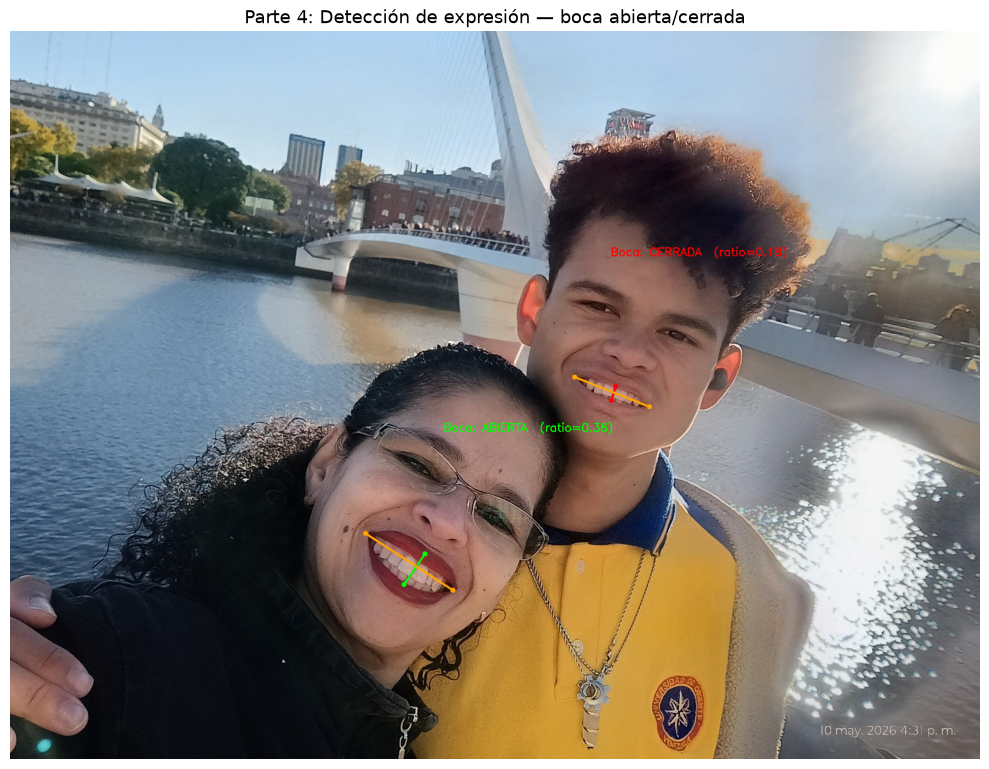

In [10]:
# =============================================================================
# Parte 4: Detectar si la boca está abierta o cerrada usando el ratio
# apertura_vertical / ancho_horizontal de la boca.
# La función dist_px y coords_px se definieron en la Parte 2.
# =============================================================================

# Umbral del ratio apertura/ancho que define "boca abierta".
# Aumentar si se producen falsos positivos; reducir si no detecta bocas abiertas.
UMBRAL_BOCA_ABIERTA = 0.25

imagen_expresion = imagen.copy()

print('=' * 52)
print('DETECCIÓN DE EXPRESIÓN — BOCA ABIERTA/CERRADA')
print('=' * 52)

if resultados.face_landmarks:
    for i, cara in enumerate(resultados.face_landmarks):

        # --- Cálculo del ratio ---
        # Apertura: distancia vertical entre labio superior e inferior (internos).
        apertura = dist_px(cara[13], cara[14], ancho, alto)
        # Ancho: distancia horizontal entre comisuras izquierda y derecha.
        ancho_boca = dist_px(cara[61], cara[291], ancho, alto)
        # El ratio mide qué fracción del ancho representa la apertura.
        ratio = apertura / ancho_boca if ancho_boca > 0 else 0.0

        boca_abierta = ratio > UMBRAL_BOCA_ABIERTA
        estado = 'ABIERTA' if boca_abierta else 'CERRADA'
        # Verde si abierta, rojo si cerrada (colores BGR).
        color_estado = (0, 255, 0) if boca_abierta else (0, 0, 255)

        # --- Consola ---
        print(f'\n  Rostro {i + 1}:')
        print(f'    Apertura vertical  (lm 13→14):  {apertura:>7.1f} px')
        print(f'    Ancho boca         (lm 61→291): {ancho_boca:>7.1f} px')
        print(f'    Ratio apertura/ancho:           {ratio:>7.3f}')
        print(f'    Umbral configurado:             {UMBRAL_BOCA_ABIERTA:>7.3f}')
        print(f'    → Boca {estado}')

        # --- Dibujo sobre la imagen ---

        # Línea de apertura vertical (rojo/verde según estado).
        p13  = coords_px(cara[13],  ancho, alto)
        p14  = coords_px(cara[14],  ancho, alto)
        cv2.line(imagen_expresion, p13, p14, color_estado, 3)
        cv2.circle(imagen_expresion, p13, 6, color_estado, -1)
        cv2.circle(imagen_expresion, p14, 6, color_estado, -1)

        # Línea de ancho horizontal (naranja).
        p61  = coords_px(cara[61],  ancho, alto)
        p291 = coords_px(cara[291], ancho, alto)
        cv2.line(imagen_expresion, p61, p291, (0, 165, 255), 3)
        cv2.circle(imagen_expresion, p61,  6, (0, 165, 255), -1)
        cv2.circle(imagen_expresion, p291, 6, (0, 165, 255), -1)

        # Etiqueta de estado sobre la frente del rostro detectado.
        frente = coords_px(cara[10], ancho, alto)
        texto_x = max(10, frente[0] - 120)
        texto_y = max(40, frente[1] - 30)
        cv2.putText(
            imagen_expresion,
            f'Boca: {estado}  (ratio={ratio:.2f})',
            (texto_x, texto_y),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.9,
            color_estado,
            2
        )

    print()
    print('✓ Detección de expresión completada.')
    print(f'  Umbral utilizado: {UMBRAL_BOCA_ABIERTA}')
    print('  Tip: ajustá UMBRAL_BOCA_ABIERTA si el resultado no coincide con la imagen.')
else:
    print('\n✗ No se detectaron rostros.')

plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(imagen_expresion, cv2.COLOR_BGR2RGB))
plt.title('Parte 4: Detección de expresión — boca abierta/cerrada', fontsize=13)
plt.axis('off')
plt.tight_layout()
plt.show()

---

## Reflexión y Conclusiones

### ¿Qué acabamos de hacer?

En este notebook completamos seis tareas sobre los mismos 478 landmarks que detectamos en el notebook base:

| Tarea | Concepto clave |
|---|---|
| Solo landmarks de los ojos | Acceso por índice a un subset de landmarks |
| Colores por región | Mapa índice → color; regiones anatómicas del FaceMesh |
| Landmarks numerados | `cv2.putText()` con fuente adaptada al tamaño de imagen |
| Medición de distancias | Distancia euclidiana en coordenadas de píxeles |
| Malla facial | `cv2.line()` sobre pares de landmarks definidos manualmente |
| Detección de expresión | Ratio de distancias + umbral para tomar una decisión binaria |

### Lo más importante

- Los **landmarks son coordenadas normalizadas**: hay que multiplicar por el ancho/alto de la imagen antes de operar en píxeles.
- Las **distancias absolutas no son comparables** entre imágenes de distintos tamaños; los **ratios** sí lo son.
- Un **umbral** es un hiperparámetro que hay que ajustar empíricamente según el contexto.

### Próximos pasos

**Nivel intermedio:**
- Extender la detección de expresiones a otras (ojos cerrados, cejas levantadas).
- Calcular índices de simetría facial (diferencia entre lado izquierdo y derecho).

**Nivel avanzado:**
- Aplicar el mismo análisis a video en tiempo real con `cv2.VideoCapture(0)`.
- Superponer filtros (imágenes PNG con transparencia) alineados con la malla.
- Exportar las mediciones a un DataFrame de pandas para análisis estadístico.

---

## Referencias y Créditos

### Documentación oficial

- [MediaPipe Face Landmarker](https://ai.google.dev/edge/mediapipe/solutions/vision/face_landmarker?hl=es-419)
- [Mapa de índices del FaceMesh (478 puntos)](https://ai.google.dev/static/mediapipe/images/solutions/face_landmarker_keypoints.png)
- [OpenCV Python — cv2.putText](https://docs.opencv.org/4.x/d6/d6e/group__imgproc__draw.html)
- [OpenCV Python — cv2.line](https://docs.opencv.org/4.x/d6/d6e/group__imgproc__draw.html)

### Bibliotecas utilizadas

- **MediaPipe** — Google LLC (Apache License 2.0)
- **OpenCV** — OpenCV Team (Apache License 2.0)
- **NumPy** — NumPy Developers (BSD License)
- **Matplotlib** — Matplotlib Development Team (PSF-based License)

---

**Materiales desarrollados por Matías Barreto, 2026**  
**Tecnicatura Superior en Ciencias de Datos e IA, IFTS24**

---